In [1]:
# 手写数字识别
# 实际是对数字 从 1-9的数字识别

# 卷积池化的本质：将图片做升维
# 1、将一张图片能够影响结果的因素变多
# 2、一张图片存在的属性：宽、高、通道（N张图片N个通道），黑白图片为一个通道
# 3、先将一张图片通过卷积核进行升维，升维堆叠起来的称为 future map （特征图）
# 4、在通过池化层降维，池化不会降低特征数
# 5、通过提高通道数 做升维，使能从多个角度理解一张图片
# 6、再通进行降维（通道数不变）
# 7、降低维度，压平压扁
# 8、经过全连接层


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from sympy.parsing.sympy_parser import null
from torchvision import datasets, transforms
import matplotlib.pyplot as plt  #损失值绘制
import numpy as np

In [3]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        # 第一个卷积层，黑白图片第一个卷积层通道数为1，输出通道32，卷积核大小（遍历大小）
        # 一个输入通道，32个输出通道，卷积核大小为32， 边界填充为1。（卷积和大小为3，padding为1时间，卷积前面积和卷积后面积是一样的）
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        # 第二个卷积层，第二层卷积输入与上一层输出需要保持一致
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)

        # 池化层，池化层使用卷积核大小，stride与卷积核大小一致时，将跳过上一次使用到的特种
        self.pooling = nn.MaxPool2d(kernel_size=2, stride=2)

        # dropout层：防止过拟合，训练时使用其中一部分参数，预测时使用所有数据
        self.dropout = nn.Dropout(0.25)  # 0.25对应dropout ratio
        self.dropout2 = nn.Dropout(0.5)

        # 全连接层，设置内容为前面输出维度数量，最后一次卷积后通道数量
        self.fc1 = nn.Linear(64 * 7 * 7, 128)  # 28 * 28 -> 14*14 -> 7*7 降维到 128
        self.fc2 = nn.Linear(128, 10)  # 输出10个类别

        # 正向传播，将初始化中内容串联起来

    def forward(self, x):
        # 第一个卷积块，卷积 -> ReLu -> 池化
        x = self.pooling(F.relu(self.conv1(x)))
        # 第二个卷积快：卷积 -> ReLu -> 池化
        x = self.pooling(F.relu(self.conv2(x)))
        # 得到最后结果后做 -> Dropout操作
        x = self.dropout(x)

        # Flatten 从4维数组 -> 2维数组，使用reshape或view转换
        x = x.view(-1, 64 * 7 * 7)  # 将四位数组转为2维数组，-1表示batchsize

        # 两层全连接，将（batchsize , 64*7*7）变为 -> （batchsize， 128）
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        # （batchsize， 128）-> （batchsize， 10）,最后进行类别识别
        x = self.fc2(x)
        return x

In [4]:
# 数据预训练
# compose函数将一些数据预处理的逻辑组合在一起
transform = transforms.Compose([
    transforms.ToTensor(),  # 把数据转为Tensor
    transforms.Normalize((0.1307,), (0.3081,))  # 数据标准归一化，防止过拟合，减少噪声
])

In [5]:
# 模型下载并加载训练与测试数据集，同事也应用transform逻辑对图片进行预处理
# train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
# test_dataset = datasets.MNIST(root='./data', train=False, transform=transform, download=True)

# 从本地读取数据
from ReadLocalDataSet import MstCustomDataset

train_dataset = MstCustomDataset(root='./my_mnist_model', train=True, transform=transform)
test_dataset = MstCustomDataset(root='./my_mnist_model', train=False, transform=transform)


In [6]:
# 创建数据加载器
# 从train_dataset中获取一批一批数据，并将每一批中数据打乱顺序后在读取数据
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)  # shuffle：打乱数据
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

In [7]:
# 4、检测是否有可用GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [8]:
# 5、初始化模型、损失函数和优化器（这三件套应该知道了吧！！！）
model = CNN().to(device)
criterion = nn.CrossEntropyLoss()  #分类任务使用CrossEntropyLoss
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [9]:
# 6、训练函数,针对什么模型训练，基于cpu/gpu，通过train_loader获取训练数据，optimizer对模型参数进行更新，epoch当前训练到第几轮
# model:针对什么模型训练
# device:基于CPU运算还是GPU运算
# train_loader: 获取训练数据
# optimzer：获取模型进行update更新
# epoch：训练第几轮
def train(model, device, train_loader, optimizer, epoch):
    model.train()  # 将模型设置为训练模式
    train_loss = 0  # 训练中的损失值
    correct = 0  # 训练中的准确率
    # 分批训练
    for batch_idx, (data, target) in enumerate(train_loader):
        # data 是一个批次数据 x， 一个批次 64张图片
        # target 是一个批次的数据 y， 一个批次64张图片对应的分类结果（0 ~ 9）

        # 将【数据 + 模型】放到指定训练环境中
        data = data.to(device)
        target = target.to(device)
        optimizer.zero_grad()

        # 正向传播，预测结果
        output = model(data)
        # 计算损失值
        loss = criterion(output, target)

        # 反向传播，使用loss对权重w求偏导
        loss.backward()
        # 参数更新
        optimizer.step()
        # 把每批次的loss加和
        train_loss += loss.item()

        # 获取最终结果，dim = 1：按照索引 1 这个维度求最大,keepdim=True 保持维度数量
        prediction = output.argmax(dim=1, keepdim=True)  # 获取预测结果，对输出的0~9进行打分
        #
        correct += prediction.eq(target.view_as(prediction)).sum().item()

        # 按批次打印内容
        if batch_idx % 100 == 0:
            print(f'训练批次（Epoch）：{epoch} [{batch_idx * len(data)}/ {len(train_loader.dataset)}'
                  f'({100. * batch_idx / len(train_loader): .0f}%]\t 损失：{loss.item():6f}')

    train_loss /= len(train_loader)  # 平均损失值
    accuracy = 100. * correct / len(train_loader.dataset)

    print(f'训练集：平均损失：{train_loss:.4f}，准确率：{correct}/{len(train_loader.dataset)}({accuracy * 100:.2f}%)')
    return train_loss, accuracy


In [10]:
# 测试函数
def test(model, device, test_loader):
    model.eval()
    test_loss = 0
    correct = 0

    # 不计算梯度
    with torch.no_grad():
        for data, target in test_loader:
            data = data.to(device)
            target = target.to(device)
            output = model(data)
            test_loss += criterion(output, target).item()
            prediction = output.argmax(dim=1, keepdim=True)
            correct += prediction.eq(target.view_as(prediction)).sum().item()

    test_loss /= len(test_loader)
    accuracy = 100. * correct / len(test_loader.dataset)
    print(f'测试集：平均损失：{test_loss:.4f}，准确率：{correct}/{len(test_loader.dataset)}({accuracy * 100:.2f}%)')
    return test_loss, accuracy


In [11]:
# 训练
epochs = 5
train_losses = []
test_losses = []
train_accuracies = []
test_accuracies = []

for epoch in range(1, epochs + 1):
    train_loss, train_acc = train(model, device, train_loader, optimizer, epoch)
    test_loss, test_acc = test(model, device, test_loader)

    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

训练批次（Epoch）：1 [0/ 60000( 0%]	 损失：2.290675
训练批次（Epoch）：1 [6400/ 60000( 11%]	 损失：0.195686
训练批次（Epoch）：1 [12800/ 60000( 21%]	 损失：0.209826
训练批次（Epoch）：1 [19200/ 60000( 32%]	 损失：0.044391
训练批次（Epoch）：1 [25600/ 60000( 43%]	 损失：0.069560
训练批次（Epoch）：1 [32000/ 60000( 53%]	 损失：0.318539
训练批次（Epoch）：1 [38400/ 60000( 64%]	 损失：0.148237
训练批次（Epoch）：1 [44800/ 60000( 75%]	 损失：0.093378
训练批次（Epoch）：1 [51200/ 60000( 85%]	 损失：0.490465
训练批次（Epoch）：1 [57600/ 60000( 96%]	 损失：0.035271
训练集：平均损失：0.1721，准确率：56839/60000(9473.17%)
测试集：平均损失：0.0406，准确率：9870/10000(9870.00%)
训练批次（Epoch）：2 [0/ 60000( 0%]	 损失：0.086373
训练批次（Epoch）：2 [6400/ 60000( 11%]	 损失：0.126204
训练批次（Epoch）：2 [12800/ 60000( 21%]	 损失：0.064996
训练批次（Epoch）：2 [19200/ 60000( 32%]	 损失：0.023876
训练批次（Epoch）：2 [25600/ 60000( 43%]	 损失：0.021967
训练批次（Epoch）：2 [32000/ 60000( 53%]	 损失：0.363231
训练批次（Epoch）：2 [38400/ 60000( 64%]	 损失：0.141213
训练批次（Epoch）：2 [44800/ 60000( 75%]	 损失：0.072765
训练批次（Epoch）：2 [51200/ 60000( 85%]	 损失：0.178092
训练批次（Epoch）：2 [57600/ 60000( 96%]	 损

In [12]:
# 保存模型
torch.save(model.state_dict(), './model.pth')
print("模型已保存")

模型已保存


C:\Users\user\AppData\Local\Temp\ipykernel_26784\2780688320.py:19: UserWarning: Glyph 27169 (\N{CJK UNIFIED IDEOGRAPH-6A21}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_26784\2780688320.py:19: UserWarning: Glyph 22411 (\N{CJK UNIFIED IDEOGRAPH-578B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_26784\2780688320.py:19: UserWarning: Glyph 25439 (\N{CJK UNIFIED IDEOGRAPH-635F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_26784\2780688320.py:19: UserWarning: Glyph 22833 (\N{CJK UNIFIED IDEOGRAPH-5931}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_26784\2780688320.py:19: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_26784\2780688320.py:19: UserWarning: Glyph 32451 (\N{CJK 

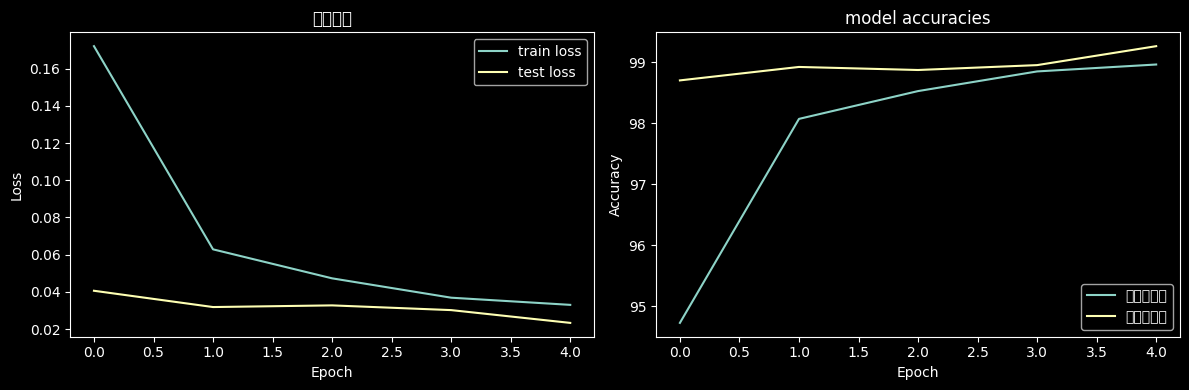

In [13]:
 # 可视化训练过程
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='train loss')
plt.plot(test_losses, label='test loss')
plt.title('模型损失')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='训练准确率')
plt.plot(test_accuracies, label='测试准确率')
plt.title('model accuracies')  # 模型准确率
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

['CNN', 'F', 'In', 'MstCustomDataset', 'Out', '_', '__', '___', '__builtin__', '__builtins__', '__doc__', '__loader__', '__name__', '__package__', '__spec__', '_dh', '_i', '_i1', '_i10', '_i11', '_i12', '_i13', '_i14', '_i2', '_i3', '_i4', '_i5', '_i6', '_i7', '_i8', '_i9', '_ih', '_ii', '_iii', '_oh', '_pydevd_bundle', 'criterion', 'datasets', 'device', 'epoch', 'epochs', 'exit', 'get_ipython', 'model', 'nn', 'np', 'null', 'open', 'optim', 'optimizer', 'plt', 'pydev_jupyter_vars', 'quit', 'test', 'test_acc', 'test_accuracies', 'test_dataset', 'test_loader', 'test_loss', 'test_losses', 'torch', 'train', 'train_acc', 'train_accuracies', 'train_dataset', 'train_loader', 'train_loss', 'train_losses', 'transform', 'transforms']
True


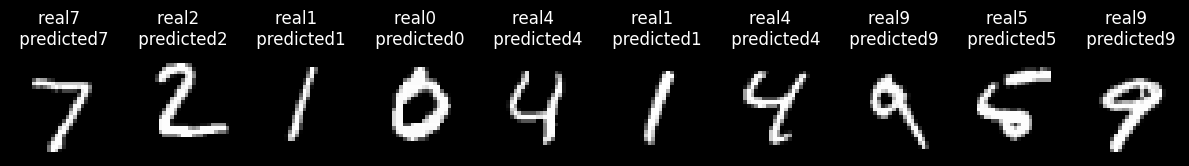

In [14]:
# 预测示例函数
print(dir())
print('model' in dir())


def preidct_show(model, test_loader, device, num_images=10):
    model.eval()
    dataiter = iter(test_loader)
    images, labels = next(dataiter)

    images, labels = images.to(device), labels.to(device)
    outputs = model(images)
    _, predicted = torch.max(outputs, 1)

    # 显示图片
    fig = plt.figure(figsize=(12, 4))
    for i in range(num_images):
        ax = fig.add_subplot(1, num_images, i + 1)
        img = images[i].cpu().numpy().squeeze()
        ax.imshow(img, cmap='gray')
        ax.set_title(f'real{labels[i].item()} \n predicted{predicted[i].item()}')
        ax.axis('off')
    plt.tight_layout()
    plt.show()


preidct_show(model, test_loader, device)

In [15]:
# 评估每个类别准确率
# 评估什么模型，在什么环境下，用什么数据集
def num_accuracy(model, data_loader, device):
    model.eval()

# 计算类别准确性、

In [16]:
# TensorBoard 训练模型监控
# 训练耗时长，记录信息多 等情况下，需要使用这个
# 数据的可视化，预测结果都可以放在 记录模型中